# Filter the Video 

In [3]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# === INPUT & OUTPUT PATHS ===
input_path = "data/group_11_fixed.mp4"      # path to your original video
output_path = "output/group_11_fixed__Gaussianblur.mp4"  # where to save the filtered video

# === READ INPUT VIDEO ===
cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise IOError("Error: cannot open video file!")

# === GET VIDEO PROPERTIES ===
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_size = (width, height)

# === DEFINE VIDEO WRITER ===
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, frame_size)

# === FRAME-BY-FRAME PROCESSING ===
while True:
    ret, frame = cap.read()
    if not ret:
        break  # no more frames

    # --- Apply filter (example: Gaussian blur) ---
    filtered_frame = cv2.GaussianBlur(frame, (5, 5), 0)
    
    # Optional: you could use other filters:
    # filtered_frame = cv2.medianBlur(frame, 5)
    # filtered_frame = cv2.bilateralFilter(frame, 9, 75, 75)

    # --- Write the filtered frame ---
    out.write(filtered_frame)

# === CLEAN UP ===
cap.release()
out.release()

print("✅ Filtered video saved successfully at:", output_path)


✅ Filtered video saved successfully at: output/group_11_fixed__Gaussianblur.mp4


- Conclusion no need for simple filtering bluring etc.. , The video is already clean. Adding filtering at this stage might be unnecessary. To check it lets look at the frequency domain of the entire fixed video. 


Video array shape: (128, 128, 128)


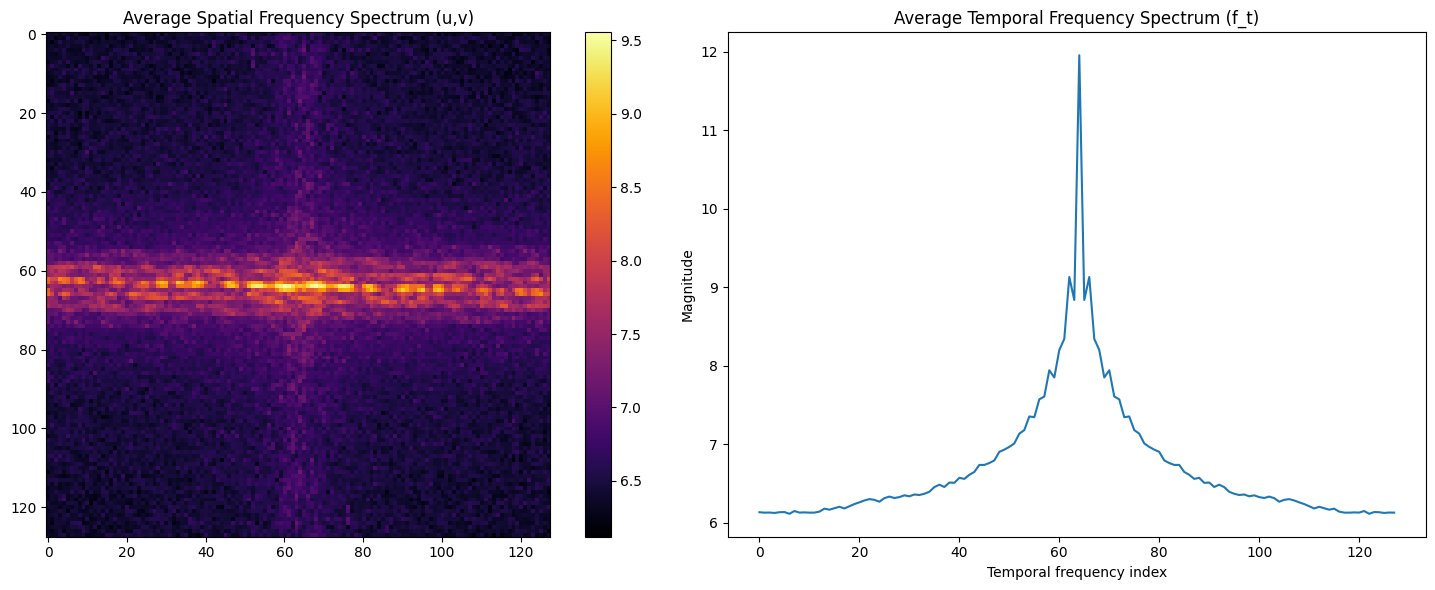

In [ ]:
video_path = "data/group_11_fixed.mp4"  
cap = cv2.VideoCapture(video_path)

frames = []
frame_count = 0
max_frames = 128  # limit to 128 frames for efficiency

while True:
    ret, frame = cap.read()
    if not ret or frame_count >= max_frames:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (128, 128))
    frames.append(gray)
    frame_count += 1

cap.release()

video_array = np.stack(frames, axis=0)  # shape (T, H, W)
print(f"Video array shape: {video_array.shape}")

# --- Compute 3D FFT ---
fft3d = np.fft.fftn(video_array)
fft3d_shifted = np.fft.fftshift(fft3d)
magnitude = np.log(np.abs(fft3d_shifted) + 1e-8)

# --- Compute projections ---
# Average over time to see spatial frequency distribution
spatial_spectrum = np.mean(magnitude, axis=0)

# Average over space to see temporal frequency distribution
temporal_spectrum = np.mean(np.mean(magnitude, axis=1), axis=1)

# --- Visualize ---
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(spatial_spectrum, cmap='inferno')
plt.title('Average Spatial Frequency Spectrum (u,v)')
plt.colorbar()

plt.subplot(1,2,2)
plt.plot(temporal_spectrum)
plt.title('Average Temporal Frequency Spectrum (f_t)')
plt.xlabel('Temporal frequency index')
plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()


Video array shape: (128, 128, 128)


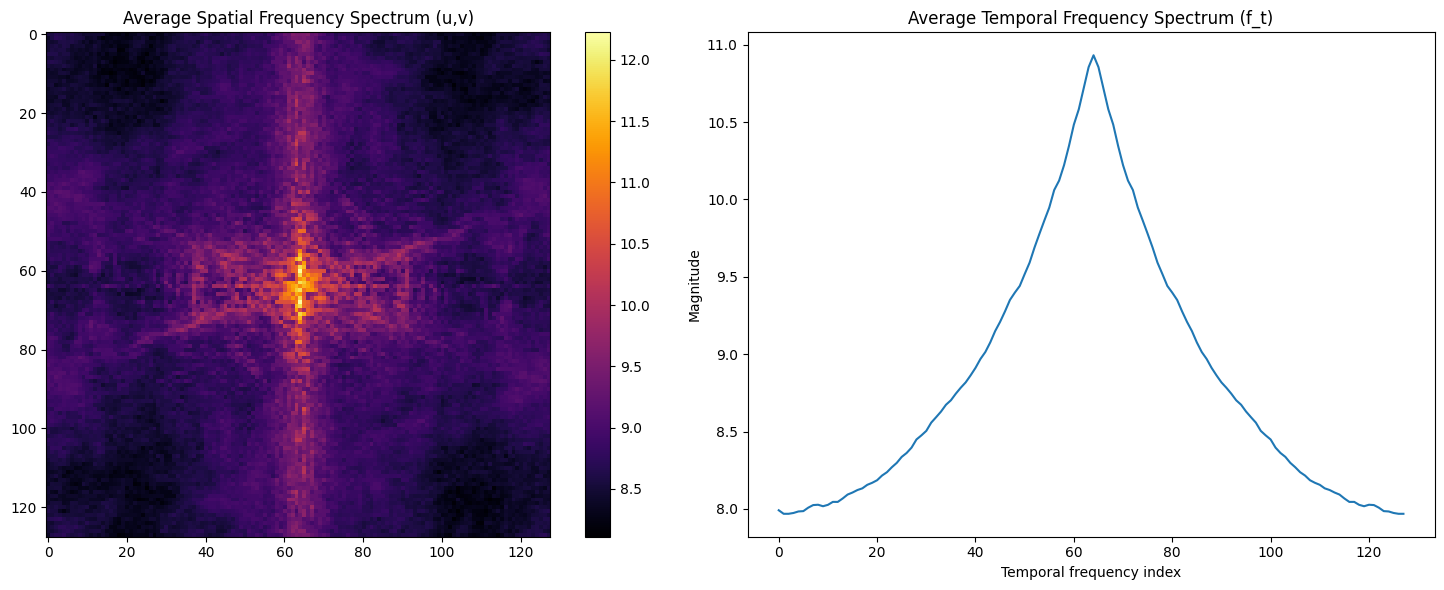

In [8]:
video_path = "data/group_11_dynamic.mp4"  
cap = cv2.VideoCapture(video_path)

frames = []
frame_count = 0
max_frames = 128  # limit to 128 frames for efficiency

while True:
    ret, frame = cap.read()
    if not ret or frame_count >= max_frames:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (128, 128))
    frames.append(gray)
    frame_count += 1

cap.release()

video_array = np.stack(frames, axis=0)  # shape (T, H, W)
print(f"Video array shape: {video_array.shape}")

# --- Compute 3D FFT ---
fft3d = np.fft.fftn(video_array)
fft3d_shifted = np.fft.fftshift(fft3d)
magnitude = np.log(np.abs(fft3d_shifted) + 1e-8)

# --- Compute projections ---
# Average over time to see spatial frequency distribution
spatial_spectrum = np.mean(magnitude, axis=0)

# Average over space to see temporal frequency distribution
temporal_spectrum = np.mean(np.mean(magnitude, axis=1), axis=1)

# --- Visualize ---
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(spatial_spectrum, cmap='inferno')
plt.title('Average Spatial Frequency Spectrum (u,v)')
plt.colorbar()

plt.subplot(1,2,2)
plt.plot(temporal_spectrum)
plt.title('Average Temporal Frequency Spectrum (f_t)')
plt.xlabel('Temporal frequency index')
plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()


# Canny edge detector ? 

In [9]:
import cv2

input_path = "data/group_11_fixed.mp4"
output_path = "output/edges_output.mp4"

cap = cv2.VideoCapture(input_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
w, h = int(cap.get(3)), int(cap.get(4))

out = cv2.VideoWriter(output_path,
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps, (w, h), isColor=False)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    out.write(edges)

cap.release()
out.release()
print("✅ Saved edge video to:", output_path)


✅ Saved edge video to: output/edges_output.mp4


- I don't know how we could use it but seems interesting , to follow edges 


# Hough Transform ? 

- Just a basic line detector 

# Test of Pre-processing Opening & closing 

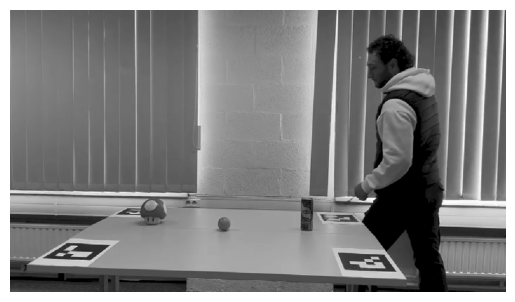

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv 
img =cv.imread('oneFrame.png',cv.IMREAD_GRAYSCALE)/255
plt.axis("off")  # Hide axes
plt.imshow(img,cmap="gray")

(np.float64(-0.5), np.float64(1056.5), np.float64(600.5), np.float64(-0.5))

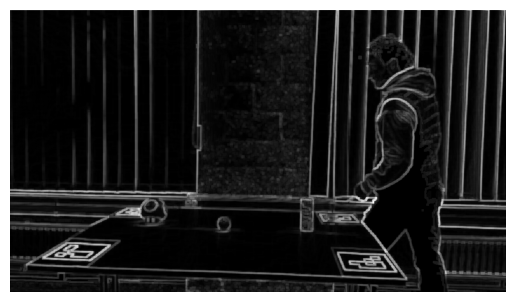

In [14]:
s = 5
SE= cv.getStructuringElement(cv.MORPH_RECT,(s,s))
# plotting the contour 
dilated_img = cv.dilate(img,SE)
eroded_img = cv.erode(img,SE)
contour = dilated_img - eroded_img

plt.imshow(contour,cmap="gray")
plt.axis("off")  # Hide axes

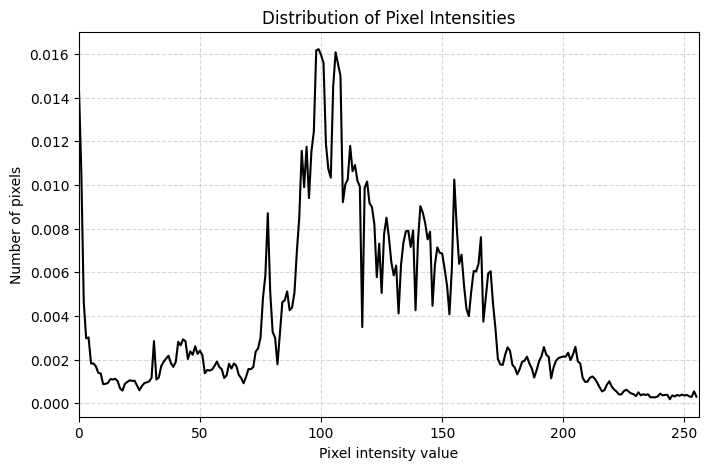

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load your image ---
img = cv2.imread('oneFrame.png')  # or a frame from your video
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- Compute histogram ---
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist = hist / hist.sum()  # Normalize

# --- Plot the distribution ---
plt.figure(figsize=(8, 5))
plt.title('Distribution of Pixel Intensities')
plt.xlabel('Pixel intensity value')
plt.ylabel('Number of pixels')
plt.plot(hist, color='black')
plt.xlim([0, 256])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


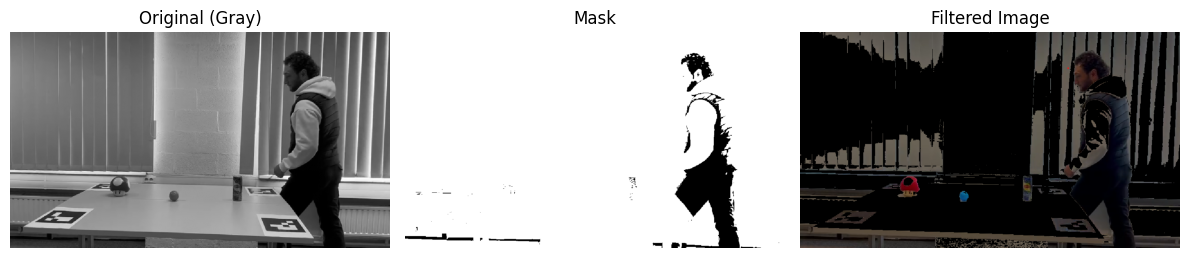

Filtered image saved as 'filtered_image.jpg'


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Load image ---
img = cv2.imread('oneFrame.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

T = 100
# --- Create mask for foreground (pixels >= T) ---
_, mask_foreground = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)

# --- Invert mask to keep background instead ---
mask_background = cv2.bitwise_not(mask_foreground)

# --- Apply background mask (keep background, black out foreground) ---
filtered_img = cv2.bitwise_and(img, img, mask=mask_background)

# --- Show with matplotlib (for inline visualization) ---
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title('Original (Gray)')
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Mask')
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Filtered Image')
plt.imshow(cv2.cvtColor(filtered_img, cv2.COLOR_BGR2RGB))  # convert BGR→RGB for plt
plt.axis('off')

plt.tight_layout()
plt.show()

# --- Save the filtered image ---
cv2.imwrite('filtered_image.jpg', filtered_img)
print("Filtered image saved as 'filtered_image.jpg'")


## USING contour package

In [31]:
import numpy as np
import cv2 as cv
 
img = cv.imread('oneFrame.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
contours,hierarchy = cv.findContours(img, 1, 2)
cnt = contours[0]
M = cv.moments(cnt)
cnt[0][0][1] -5

np.int32(595)

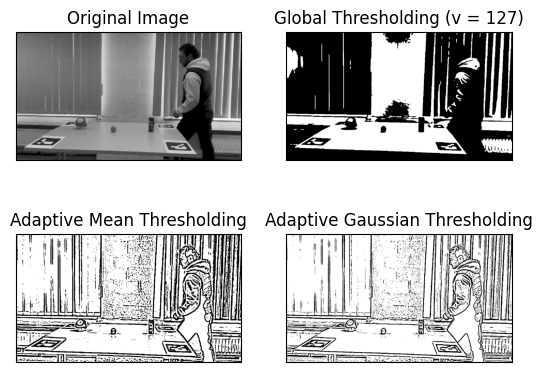

In [32]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
img = cv.imread('oneFrame.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img = cv.medianBlur(img,5)
ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)
titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]
for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

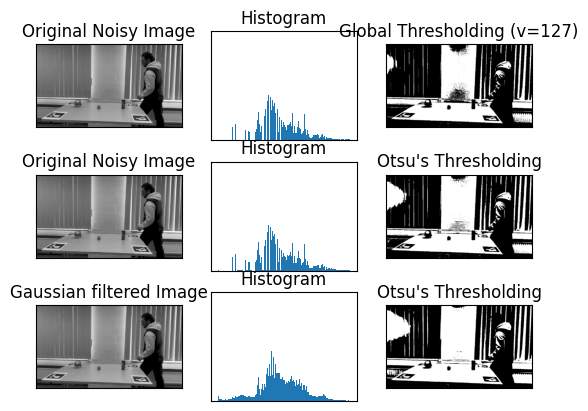

In [33]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
img = cv.imread('oneFrame.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
# global thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
# Otsu's thresholding after Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
# plot all the images and their histograms
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
          'Original Noisy Image','Histogram',"Otsu's Thresholding",
          'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

# Finding a color object